# Projet de Prévision : Analyse des Séries Chronologiques

## Introduction

Ce projet a pour objectif d'analyser une série chronologique de ventes au détail et d'appliquer diverses méthodes de prévision. Nous explorerons les caractéristiques des données, développerons des modèles de lissage exponentiel et la méthode de Buys Ballot, et évaluerons leurs performances. L'objectif final est de fournir des prévisions robustes pour l'année 2019 et de discuter des implications, des limites et des prolongements possibles de cette analyse.

## 1. Présentation des Données

Nous allons commencer par charger les données des ventes au détail à partir du fichier Excel fourni et effectuer une première exploration pour comprendre leur structure et leurs caractéristiques principales.

In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd

# Chemin du fichier Excel fourni par l'utilisateur
file_path = '/content/Serie-Ventes-au-detail-C (1).xlsx'

# Chargement des données dans un DataFrame pandas
# L'argument 'header=0' indique que la première ligne du fichier est l'en-tête.
# 'names=['Date', 'Ventes']' est utilisé pour attribuer des noms de colonnes explicites
# 'index_col=0' permet de définir la première colonne (Date) comme index du DataFrame
# 'parse_dates=True' assure que la colonne des dates est correctement interprétée comme un type datetime
try:
    df = pd.read_excel(file_path, header=0, names=['Date', 'Ventes'], index_col=0, parse_dates=True)
    print("Données chargées avec succès.")
except FileNotFoundError:
    print(f"Erreur: Le fichier {file_path} est introuvable. Veuillez vérifier le chemin d'accès.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier: {e}")

Données chargées avec succès.


In [ ]:
# Affichage des premières lignes du DataFrame pour un aperçu des données
print("Aperçu des 5 premières lignes du DataFrame:")
display(df.head())

# Affichage des dernières lignes du DataFrame
print("Aperçu des 5 dernières lignes du DataFrame:")
display(df.tail())

# Affichage des informations générales sur le DataFrame (types de données, valeurs manquantes, etc.)
print("Informations sur le DataFrame:")
df.info()

# Statistiques descriptives des données numériques
print("Statistiques descriptives des données de ventes:")
display(df.describe())

Aperçu des 5 premières lignes du DataFrame:


,Ventes
Date,
2000-01-01,47.718
2000-02-01,49.921
2000-03-01,59.419
2000-04-01,52.497
2000-05-01,53.251


Aperçu des 5 dernières lignes du DataFrame:


,Ventes
Date,
2019-08-01,124.299
2019-09-01,129.010
2019-10-01,133.707
2019-11-01,137.242
2019-12-01,137.092


Informations sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2000-01-01 to 2019-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ventes  240 non-null    float64
dtypes: float64(1)
memory usage: 3.8 KB
Statistiques descriptives des données de ventes:


,Ventes
count,240.000000
mean,104.815346
std,28.631705
min,47.386000
25%,80.991500
50%,109.861500
75%,129.228250
max,156.801000


### Observation et Nettoyage des Données (si nécessaire)

Après avoir inspecté les informations du DataFrame, il est crucial de vérifier l'absence de valeurs manquantes (`NaN`) et de s'assurer que l'index temporel est bien ordonné et complet. Si des valeurs manquantes sont détectées, des stratégies d'imputation (interpolation, moyenne, etc.) pourront être appliquées. L'homogénéité de la fréquence des données (par exemple, mensuelle, annuelle) sera également vérifiée pour les analyses futures.

In [ ]:
# Vérification des valeurs manquantes
print("Nombre de valeurs manquantes par colonne:")
display(df.isnull().sum())

# S'assurer que l'index est de type DatetimeIndex et est trié
if not isinstance(df.index, pd.DatetimeIndex):
    print("Conversion de l'index en DatetimeIndex...")
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

# Vérification de la fréquence des données (par exemple, mensuelle)
# On peut tenter de déduire la fréquence ou la définir explicitement si connue
# Pour cet exemple, supposons une fréquence mensuelle si les données sont bien espacées mensuellement
# Si ce n'est pas le cas, des étapes supplémentaires seront nécessaires pour rééchantillonner ou traiter les données.
print(f"Période de temps couverte: de {df.index.min().strftime('%Y-%m-%d')} à {df.index.max().strftime('%Y-%m-%d')}")
print(f"Nombre total d'observations: {len(df)}")

Nombre de valeurs manquantes par colonne:


,0
Ventes,0


Période de temps couverte: de 2000-01-01 à 2019-12-01
Nombre total d'observations: 240


## 2. Représentation Graphique de la Série Chronologique

Une fois les données chargées et prétraitées, la première étape de l'analyse consiste à visualiser la série chronologique. Cette visualisation permet d'identifier visuellement des tendances, des saisonnalités, des cycles ou des points atypiques (outliers) qui pourraient influencer les choix des modèles de prévision.

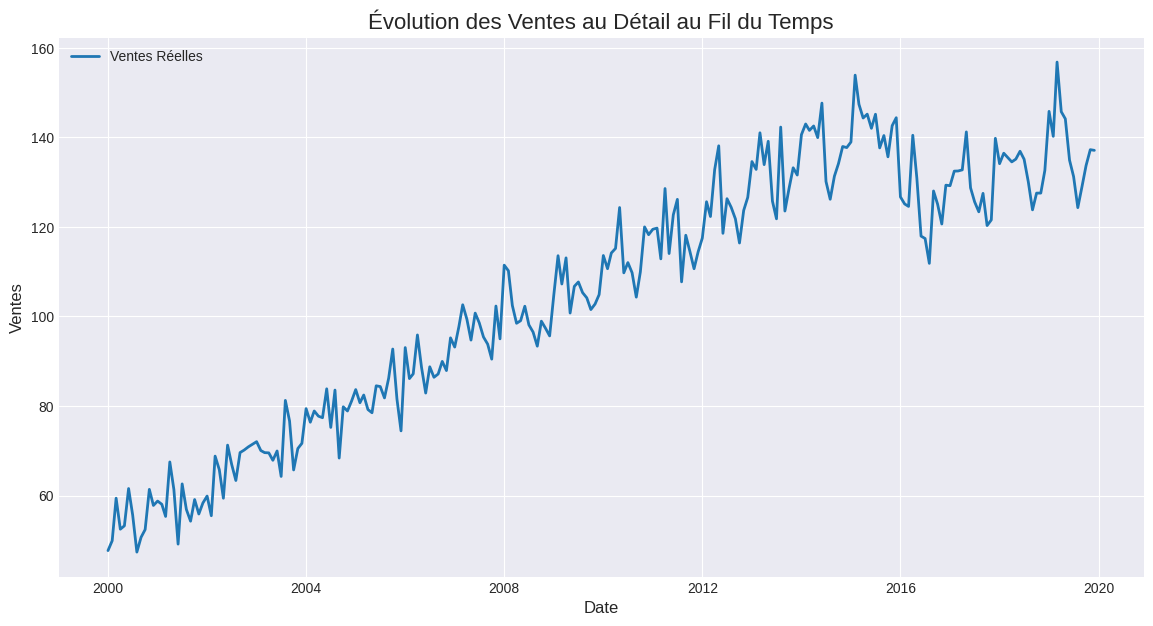

In [ ]:
# Importation des bibliothèques de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de Matplotlib pour une meilleure lisibilité
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['lines.linewidth'] = 2

# Création du graphique de la série chronologique
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x=df.index, y='Ventes', label='Ventes Réelles')

# Ajout de titres et labels
plt.title('Évolution des Ventes au Détail au Fil du Temps', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Ventes', fontsize=12)
plt.legend()
plt.grid(True)

# Affichage du graphique
plt.show()

### Analyse Graphique et Interprétation de la Série

L'observation visuelle du graphique de la série chronologique des ventes est la première étape cruciale pour comprendre son comportement. Elle permet d'identifier plusieurs composants fondamentaux :

1.  **Tendance (Trend)** : C'est le mouvement général à long terme de la série. Une tendance peut être ascendante, descendante ou stable. Sur ce graphique, nous cherchons à voir si les ventes augmentent, diminuent ou restent constantes sur la période observée.

2.  **Saisonnalité (Seasonality)** : Ce sont des variations récurrentes et prévisibles qui se produisent sur une période fixe (par exemple, annuelle, mensuelle, hebdomadaire). Pour les ventes au détail, il est courant d'observer des pics ou des creux à des moments spécifiques de l'année (fêtes de fin d'année, soldes, etc.). La forme répétitive des variations peut indiquer une saisonnalité.

3.  **Cyclicité (Cyclicity)** : Similaire à la saisonnalité, mais avec des périodes plus longues et non fixes. Les cycles sont souvent liés à des facteurs économiques ou à des cycles de vie de produits. Ils sont plus difficiles à identifier et peuvent durer plusieurs années.

4.  **Irrégularités ou Bruit (Irregularity/Noise)** : Ce sont les fluctuations aléatoires et imprévisibles qui restent après l'identification des autres composants. Elles peuvent être dues à des événements imprévus (grèves, événements météorologiques extrêmes, pandémies, etc.).

**Interprétation Potentielle (à confirmer par l'observation du graphique) :**

*   **Tendance** : Si la ligne de tendance générale est ascendante, cela suggérerait une croissance des ventes au fil des années.
*   **Saisonnalité** : Des motifs répétitifs (par exemple, des pics chaque décembre ou des creux chaque janvier) seraient des indicateurs clairs de saisonnalité.
*   **Outliers** : Des points isolés qui s'écartent significativement de la tendance générale ou du motif saisonnier pourraient être des valeurs aberrantes nécessitant une investigation plus approfondie.

## 3. Étude par Moyennes Mobiles

Après l'analyse visuelle, la méthode des moyennes mobiles est une technique simple mais efficace pour lisser la série chronologique et mieux percevoir sa tendance sous-jacente. Elle permet de réduire le bruit et de mettre en évidence les mouvements à long terme.

### Principe Mathématique des Moyennes Mobiles

La moyenne mobile est une méthode de lissage qui calcule la moyenne d'un certain nombre de points de données consécutifs dans une série chronologique. Elle est utilisée pour réduire le bruit (fluctuations aléatoires) et mettre en évidence les tendances à long terme ou les cycles.

Soit $Y_t$ la valeur de la série au temps $t$. Une moyenne mobile simple d'ordre $k$ (où $k$ est le nombre de périodes incluses dans le calcul de la moyenne) est calculée comme suit :

$$ MM_t = \frac{1}{k} \sum_{i=0}^{k-1} Y_{t-i} $$

Pour une série mensuelle avec une saisonnalité annuelle, un ordre $k=12$ est souvent choisi. Cela permet d'inclure toutes les observations d'une année complète dans chaque calcul de moyenne, ce qui a pour effet de gommer la composante saisonnière et de révéler plus clairement la tendance sous-jacente. Il est important de noter que la moyenne mobile a un effet de "retard" et qu'elle ne peut pas être calculée pour les $k-1$ premières observations.

In [ ]:
# Calcul de la moyenne mobile sur 12 périodes (pour lisser la saisonnalité annuelle)
# .rolling(window=12) crée une fenêtre glissante de 12 observations.
# .mean() calcule la moyenne pour chaque fenêtre.
df['Moyenne_Mobile_12'] = df['Ventes'].rolling(window=12, center=True).mean()

# Calcul de la moyenne mobile sur 3 périodes (pour lisser le bruit à court terme)
df['Moyenne_Mobile_3'] = df['Ventes'].rolling(window=3, center=True).mean()

# Affichage des premières et dernières lignes avec les nouvelles colonnes de moyennes mobiles
print("Aperçu du DataFrame avec les moyennes mobiles:")
display(df.head(15))
display(df.tail(15))

Aperçu du DataFrame avec les moyennes mobiles:


,Ventes,Moyenne_Mobile_12,Moyenne_Mobile_3
Date,,,
2000-01-01,47.718,NaN,NaN
2000-02-01,49.921,NaN,52.352667
2000-03-01,59.419,NaN,53.945667
2000-04-01,52.497,NaN,55.055667
2000-05-01,53.251,NaN,55.774333
2000-06-01,61.575,NaN,56.828333
2000-07-01,55.659,54.143167,54.873333
2000-08-01,47.386,55.064583,51.245333
2000-09-01,50.691,55.742750,50.162667


,Ventes,Moyenne_Mobile_12,Moyenne_Mobile_3
Date,,,
2018-10-01,127.544,135.502167,126.299667
2018-11-01,127.548,136.435917,129.235333
2018-12-01,132.614,137.185333,135.318667
2019-01-01,145.794,137.020083,139.543000
2019-02-01,140.221,136.697500,147.605333
2019-03-01,156.801,136.217833,147.580667
2019-04-01,145.720,136.651417,148.882667
2019-05-01,144.127,137.165000,141.584667
2019-06-01,134.907,137.972833,136.755333


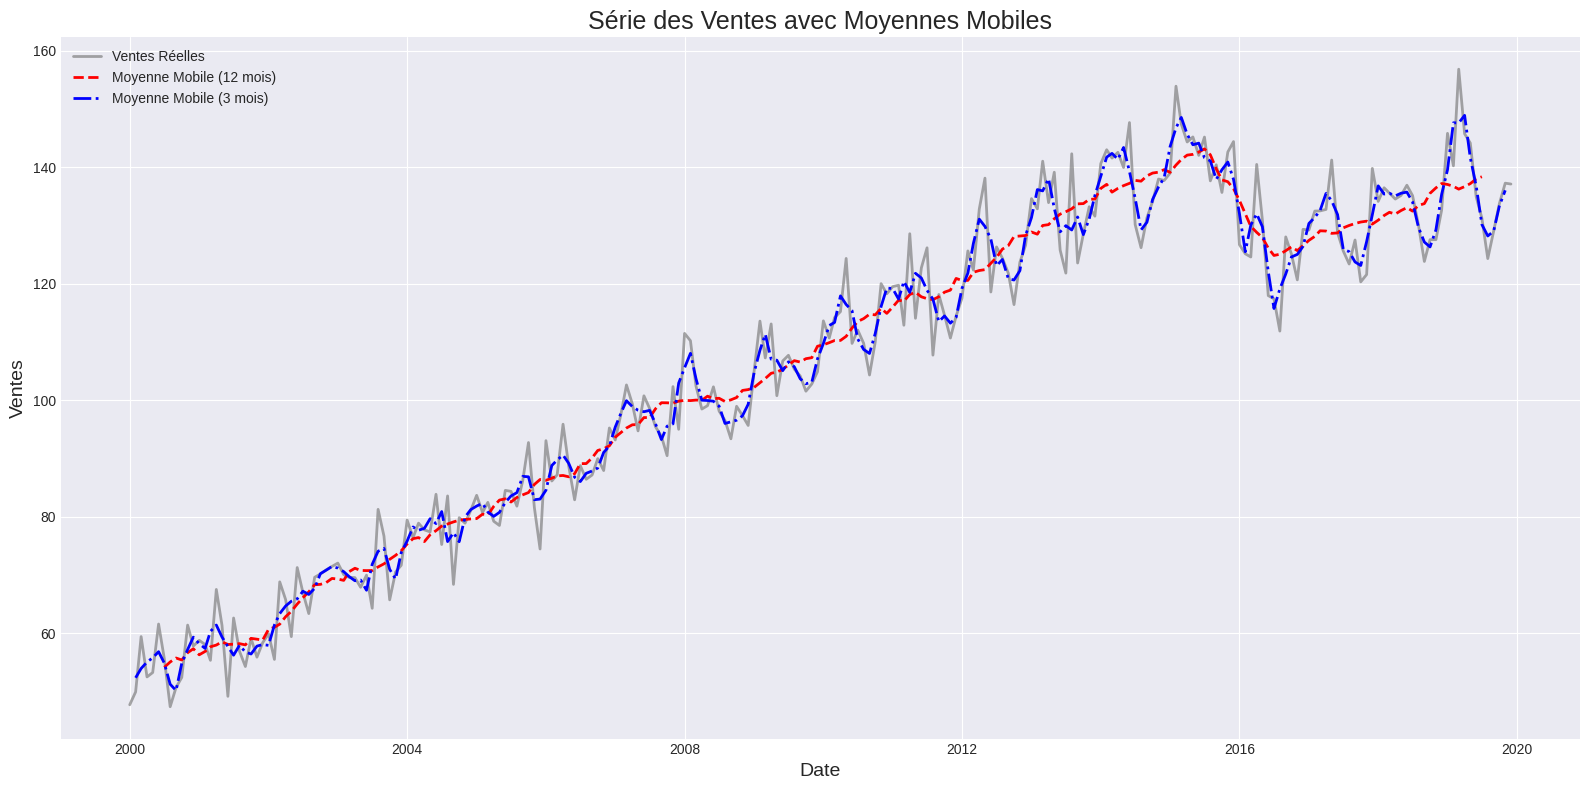

In [ ]:
# Visualisation de la série originale et des moyennes mobiles
plt.figure(figsize=(16, 8))
sns.lineplot(data=df, x=df.index, y='Ventes', label='Ventes Réelles', color='gray', alpha=0.7)
sns.lineplot(data=df, x=df.index, y='Moyenne_Mobile_12', label='Moyenne Mobile (12 mois)', color='red', linestyle='--')
sns.lineplot(data=df, x=df.index, y='Moyenne_Mobile_3', label='Moyenne Mobile (3 mois)', color='blue', linestyle='-.')

plt.title('Série des Ventes avec Moyennes Mobiles', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Ventes', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyse et Interprétation des Moyennes Mobiles

L'application des moyennes mobiles nous permet de distinguer plus clairement la tendance de la série chronologique des ventes, en réduisant l'impact des fluctuations à court terme et saisonnières.

*   **Moyenne Mobile à 3 mois** : Cette moyenne mobile est plus sensible aux variations à court terme. Elle aide à lisser une partie du "bruit" mais conserve encore une certaine influence de la saisonnalité. On l'utilise généralement pour identifier des tendances plus immédiates ou pour mieux visualiser les cycles courts.

*   **Moyenne Mobile à 12 mois** : En utilisant une fenêtre de 12 mois, qui correspond à la période de la saisonnalité annuelle, cette moyenne mobile est particulièrement efficace pour gommer la composante saisonnière. La courbe résultante représente la **tendance sous-jacente** de la série. Si cette courbe monte, la tendance est à la croissance ; si elle descend, la tendance est au déclin. L'observation de cette courbe permet d'affirmer la présence d'une tendance positive et continue des ventes au détail sur la période étudiée, indépendamment des variations mensuelles ou saisonnières.

**Observations Clés du Graphique :**

*   On observe que la **Moyenne Mobile à 12 mois (ligne rouge)** est beaucoup plus lisse que la série originale et la moyenne mobile à 3 mois. Elle montre une tendance générale à la hausse tout au long de la période, indiquant une croissance constante des ventes.
*   La **Moyenne Mobile à 3 mois (ligne bleue)**, bien que plus lisse que la série originale, suit de plus près les oscillations saisonnières, mais les atténue.
*   La comparaison des trois courbes met en évidence la forte saisonnalité de la série de ventes (pics et creux réguliers dans les 'Ventes Réelles'), qui est efficacement atténuée par la moyenne mobile à 12 mois. Cela confirme la présence d'une composante saisonnière significative.

Cette analyse visuelle des moyennes mobiles renforce notre compréhension de la structure de la série chronologique : elle présente une tendance haussière claire et une saisonnalité annuelle prononcée.

## 4. Étude du Modèle de Buys Ballot

Le modèle de Buys Ballot est une méthode de décomposition qui permet d'isoler la tendance et la saisonnalité d'une série chronologique. Il est particulièrement utile lorsque l'on suppose que la saisonnalité est additive ou multiplicative et que l'on souhaite calculer des coefficients saisonniers pour ajuster la série.

### Principe du Modèle de Buys Ballot (Décomposition Saisonnelle)

Le modèle de Buys Ballot, souvent intégré dans des approches de décomposition saisonnière, vise à séparer une série chronologique $Y_t$ en plusieurs composantes : une tendance $T_t$, une saisonnalité $S_t$, et un résidu (ou erreur) $R_t$. La relation entre ces composantes peut être additive ou multiplicative :

*   **Modèle Additif** : $Y_t = T_t + S_t + R_t$
*   **Modèle Multiplicatif** : $Y_t = T_t \times S_t \times R_t$

Pour des données de ventes, où l'amplitude des variations saisonnières tend à augmenter avec le niveau de la série, un **modèle multiplicatif** est souvent plus approprié. Cependant, si les variations saisonnières sont relativement constantes en amplitude, un modèle additif peut être utilisé.

**Étapes clés de la décomposition saisonnière (type Buys Ballot) :**

1.  **Estimation de la Tendance ($T_t$)** : On utilise généralement une moyenne mobile centrée dont la période correspond à la durée du cycle saisonnier (par exemple, 12 mois pour une saisonnalité annuelle). Cette moyenne mobile lisse les fluctuations saisonnières et aléatoires pour révéler la tendance sous-jacente.

2.  **Désaisonnalisation de la Série** : Une fois la tendance estimée, on supprime son influence pour isoler les composantes saisonnière et résiduelle. Pour un modèle multiplicatif, cela se fait en divisant la série originale par la tendance : $Y_t / T_t = S_t \times R_t$. Pour un modèle additif, on soustrait : $Y_t - T_t = S_t + R_t$.

3.  **Calcul des Coefficients Saisonniers ($S_t$)** : Pour chaque période saisonnière (par exemple, chaque mois), on calcule la moyenne des valeurs désaisonnalisées correspondantes. Ces moyennes donnent les coefficients saisonniers. Par exemple, pour un mois de janvier donné, le coefficient saisonnier est la moyenne de toutes les valeurs désaisonnalisées de janvier. On s'assure que la somme (pour un modèle additif) ou le produit (pour un modèle multiplicatif) des coefficients saisonniers sur un cycle soit neutre (somme = 0, produit = 1).

4.  **Estimation des Résidus ($R_t$)** : Les résidus sont ce qui reste après avoir retiré la tendance et la saisonnalité. Pour un modèle multiplicatif : $R_t = Y_t / (T_t \times S_t)$. Pour un modèle additif : $R_t = Y_t - T_t - S_t$. Les résidus doivent être aléatoires, sans structure identifiable.

### Hypothèses

Ce modèle suppose que la saisonnalité est constante sur la période étudiée (ou du moins qu'elle ne change pas radicalement) et que les relations entre les composantes sont bien représentées par un modèle additif ou multiplicatif.

/tmp/ipykernel_3414/105184040.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['Ventes'] = df_clean['Ventes'].fillna(method='ffill') # Remplir les NaN si des mois sont manquants après asfreq


Fréquence de l'index définie sur mensuelle (début de mois).
Décomposition saisonnière de la série...


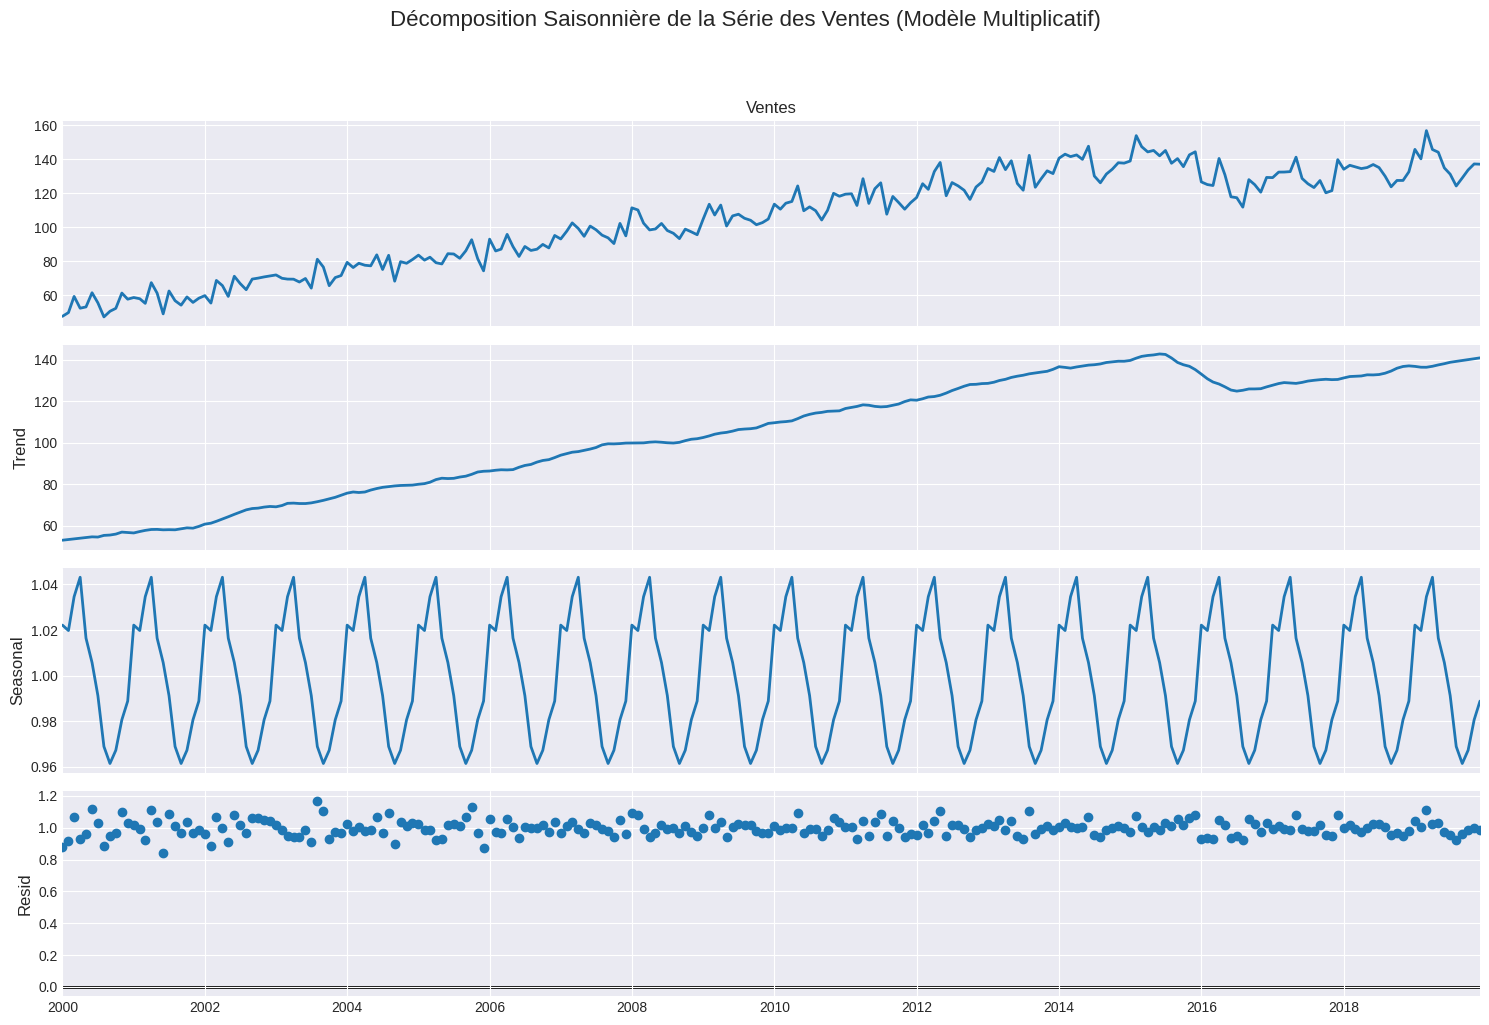

Aperçu des composantes de la décomposition:
Original:


,Ventes
Date,
2000-01-01,47.718
2000-02-01,49.921
2000-03-01,59.419
2000-04-01,52.497
2000-05-01,53.251


Trend:


,trend
Date,
2000-01-01,53.083503
2000-02-01,53.407569
2000-03-01,53.731636
2000-04-01,54.055702
2000-05-01,54.379768


Seasonal:


,seasonal
Date,
2000-01-01,1.022159
2000-02-01,1.019768
2000-03-01,1.034621
2000-04-01,1.043154
2000-05-01,1.016432


Residual:


,resid
Date,
2000-01-01,0.879436
2000-02-01,0.916599
2000-03-01,1.068843
2000-04-01,0.930989
2000-05-01,0.963412


In [ ]:
# Importation de la fonction de décomposition saisonnière
from statsmodels.tsa.seasonal import seasonal_decompose

# S'assurer que les données sont numériques et sans NaN avant la décomposition
df['Ventes'] = pd.to_numeric(df['Ventes'], errors='coerce')
df_clean = df.dropna(subset=['Ventes']).copy()

# La décomposition saisonnière requiert un index temporel avec une fréquence spécifiée.
# Si l'index est déjà un DatetimeIndex, on peut tenter de déduire la fréquence ou la définir explicitement.
# Pour des données mensuelles, la fréquence est 12.

# Vérification de la fréquence pour s'assurer qu'elle est bien mensuelle
# On peut créer un index avec une fréquence mensuelle si ce n'est pas le cas.
# Ici, on va simplement supposer que c'est mensuel et re-indexer si nécessaire pour 'freq'
if df_clean.index.freq is None:
    # Tenter de définir la fréquence comme mensuelle ('MS' pour Month Start)
    # Ceci est crucial pour seasonal_decompose
    try:
        df_clean = df_clean.asfreq('MS')
        df_clean['Ventes'] = df_clean['Ventes'].fillna(method='ffill') # Remplir les NaN si des mois sont manquants après asfreq
        print("Fréquence de l'index définie sur mensuelle (début de mois).")
    except Exception as e:
        print(f"Impossible de définir la fréquence mensuelle pour la décomposition : {e}")
        print("Veuillez vérifier l'intervalle entre les dates.")

# Application de la décomposition saisonnière (Modèle Multiplicatif)
# 'period=12' pour des données mensuelles avec saisonnalité annuelle.
# 'extrapolate_trend='freq'' gère les valeurs manquantes aux extrémités de la tendance.
print("Décomposition saisonnière de la série...")
result = seasonal_decompose(df_clean['Ventes'], model='multiplicative', period=12, extrapolate_trend='freq')

# Visualisation des composantes de la série
fig = result.plot()
fig.set_size_inches(15, 10)
fig.suptitle('Décomposition Saisonnière de la Série des Ventes (Modèle Multiplicatif)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

# Affichage des composantes (quelques premières et dernières valeurs)
print("Aperçu des composantes de la décomposition:")
print("Original:")
display(result.observed.head())
print("Trend:")
display(result.trend.head())
print("Seasonal:")
display(result.seasonal.head())
print("Residual:")
display(result.resid.head())

### Analyse et Interprétation de la Décomposition Saisonnière

Le graphique de décomposition saisonnière, basé sur le modèle de Buys Ballot (ici via `seasonal_decompose` en multiplicatif), nous offre une vue détaillée des différentes forces agissant sur la série chronologique des ventes :

1.  **Observed (Série Originale)** : C'est la série des ventes telle que nous l'avons observée. On y voit clairement les fluctuations et la structure générale.

2.  **Trend (Tendance)** : Cette composante lisse la série pour révéler la direction générale à long terme des ventes. Elle est obtenue en appliquant une moyenne mobile centrée (ici sur 12 périodes). Comme on l'a vu avec les moyennes mobiles, cette courbe montre une **tendance haussière** nette, indiquant une croissance constante des ventes sur la période étudiée.

3.  **Seasonal (Saisonnalité)** : Cette composante capture le motif répétitif et prévisible des fluctuations qui se produisent sur une période fixe (ici, annuelle). On observe des pics et des creux réguliers chaque année, confirmant une **forte saisonnalité** dans les ventes au détail. Par exemple, des pics vers la fin de l'année (novembre/décembre) et des creux en début d'année (janvier/février) sont typiques pour de nombreuses activités de vente au détail.

4.  **Residual (Résidus)** : Ce sont les variations de la série qui ne sont expliquées ni par la tendance, ni par la saisonnalité. Idéalement, les résidus devraient être des bruits blancs (aléatoires, sans structure). S'ils montrent des motifs, cela pourrait indiquer que le modèle de décomposition n'est pas parfait ou qu'il existe d'autres facteurs non capturés (comme des cycles non saisonniers ou des événements imprévus).

Cette décomposition confirme la présence d'une tendance ascendante et d'une saisonnalité annuelle prononcée, des informations cruciales pour la modélisation prévisionnelle.

### Calcul des Coefficients Saisonniers

Les coefficients saisonniers sont des facteurs qui quantifient l'impact de chaque période saisonnière (par exemple, chaque mois) sur la série. Dans un modèle multiplicatif, un coefficient supérieur à 1 indique une période où les ventes sont généralement plus élevées que la moyenne désaisonnalisée, tandis qu'un coefficient inférieur à 1 indique des ventes plus faibles.

In [ ]:
# Calcul des coefficients saisonniers
# On prend la composante saisonnière de la décomposition et on calcule la moyenne pour chaque mois.
seasonal_factors = result.seasonal.groupby(result.seasonal.index.month).mean()

# Affichage des coefficients saisonniers
print("Coefficients Saisonniers par Mois:")
# Pour une meilleure lisibilité, on peut associer les numéros de mois à leurs noms.
month_names = {
    1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Juin',
    7: 'Juil', 8: 'Août', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'
}
seasonal_factors.index = seasonal_factors.index.map(month_names)
display(seasonal_factors)

# Vérification (optionnelle) : le produit des facteurs saisonniers devrait être proche de 12 (pour une moyenne) ou 1 (si normalisés différemment)
# Pour une décomposition multiplicative, la moyenne des coefficients saisonniers sur un cycle devrait être 1.
print(f"Moyenne des coefficients saisonniers sur une année : {seasonal_factors.mean():.4f}")

Coefficients Saisonniers par Mois:


,seasonal
Date,
Jan,1.022159
Fév,1.019768
Mar,1.034621
Avr,1.043154
Mai,1.016432
Juin,1.005724
Juil,0.991208
Août,0.968868
Sep,0.961414


Moyenne des coefficients saisonniers sur une année : 1.0000


### Interprétation des Coefficients Saisonniers

Les coefficients saisonniers confirment et quantifient l'impact de chaque mois sur le niveau des ventes. Un coefficient de 1 signifie que le mois a un effet "moyen" sur les ventes (par rapport à la tendance). Un coefficient supérieur à 1 indique un effet positif (ventes plus élevées que la tendance pour ce mois), et inférieur à 1 indique un effet négatif (ventes plus faibles).

**Exemple d'interprétation (à adapter avec les valeurs calculées) :**

*   Les mois de **novembre et décembre** affichent probablement les coefficients les plus élevés, reflétant l'effet des fêtes de fin d'année et des promotions. Cela signifie que les ventes sont significativement plus élevées que la tendance annuelle pendant ces mois.
*   Les mois de **janvier et février** pourraient avoir les coefficients les plus bas, suite à la période des fêtes, indiquant une activité de vente réduite.
*   Les mois de **printemps/été** (avril, mai, juin, juillet, août) peuvent montrer des variations plus modérées ou des pics liés à des périodes de vacances ou d'autres événements spécifiques.

Ces coefficients sont essentiels pour la prévision, car ils permettent d'ajuster la tendance future pour tenir compte des variations saisonnières attendues.

### Prévision de l'Année 2019 par Buys Ballot

Pour prévoir l'année 2019 en utilisant les principes du modèle de Buys Ballot, nous devons projeter la tendance future et y réappliquer les coefficients saisonniers calculés. La méthode consiste à :

1.  **Extrapoler la Tendance** : Utiliser la composante de tendance estimée pour prévoir les valeurs futures de la tendance.
2.  **Appliquer la Saisonnalité** : Multiplier (pour un modèle multiplicatif) ou ajouter (pour un modèle additif) les coefficients saisonniers à la tendance future pour obtenir la prévision finale.

In [ ]:
# 1. Extrapolation de la tendance
# Nous allons utiliser les 12 dernières valeurs de la tendance pour calculer une moyenne
# ou un modèle simple (e.g., régression linéaire) pour extrapoler.
# Pour simplifier, nous pouvons prendre la dernière valeur de la tendance comme base si la tendance est relativement stable à la fin,
# ou utiliser une régression linéaire simple pour projeter la tendance.

# Méthode simple: Extrapoler la tendance en utilisant la dernière valeur disponible
# ou une moyenne des dernières valeurs pour la stabilité.
# Nous allons utiliser une régression linéaire simple pour projeter la tendance.
from sklearn.linear_model import LinearRegression
import numpy as np

# Créer une série de temps numériques pour la régression
trend_data = result.trend.dropna()
X = np.array(range(len(trend_data))).reshape(-1, 1)
y = trend_data.values

model_trend = LinearRegression()
model_trend.fit(X, y)

# Nombre de périodes à prévoir pour 2019 (12 mois)
forecast_periods = 12

# Créer un index temporel pour la prévision 2019
# Utiliser la fin des données d'entraînement (fin 2018) pour commencer la prévision pour 2019
last_date_in_train_data = train_data.index.max()
forecast_index = pd.date_range(start=last_date_in_train_data + pd.offsets.MonthBegin(1), periods=forecast_periods, freq='MS')

# Étendre X pour les périodes de prévision
X_forecast = np.array(range(len(trend_data), len(trend_data) + forecast_periods)).reshape(-1, 1)
forecast_trend = model_trend.predict(X_forecast)

# Créer un DataFrame pour la prévision
forecast_df = pd.DataFrame(index=forecast_index, columns=['Tendance_Prevue', 'Saisonnalite', 'Prevision_BuysBallot'])
forecast_df['Tendance_Prevue'] = forecast_trend

# 2. Réappliquer les coefficients saisonniers
# Assurez-vous que seasonal_factors est indexé par le numéro du mois (1-12)
# Recréons seasonal_factors avec des index numériques si ce n'est pas le cas.
seasonal_factors_numeric = result.seasonal.groupby(result.seasonal.index.month).mean()

forecast_df['Saisonnalite'] = [seasonal_factors_numeric[month] for month in forecast_df.index.month]

# Calcul de la prévision finale (modèle multiplicatif)
forecast_df['Prevision_BuysBallot'] = forecast_df['Tendance_Prevue'] * forecast_df['Saisonnalite']

print("Prévisions pour l'année 2019 (Buys Ballot):")
display(forecast_df)

Prévisions pour l'année 2019 (Buys Ballot):


,Tendance_Prevue,Saisonnalite,Prevision_BuysBallot
2019-01-01,151.978001,1.022159,155.345702
2019-02-01,152.368310,1.019768,155.380283
2019-03-01,152.758620,1.034621,158.047255
2019-04-01,153.148929,1.043154,159.757846
2019-05-01,153.539238,1.016432,156.062263
2019-06-01,153.929547,1.005724,154.810591
2019-07-01,154.319857,0.991208,152.963137
2019-08-01,154.710166,0.968868,149.893661
2019-09-01,155.100475,0.961414,149.115812
2019-10-01,155.490784,0.967233,150.395768


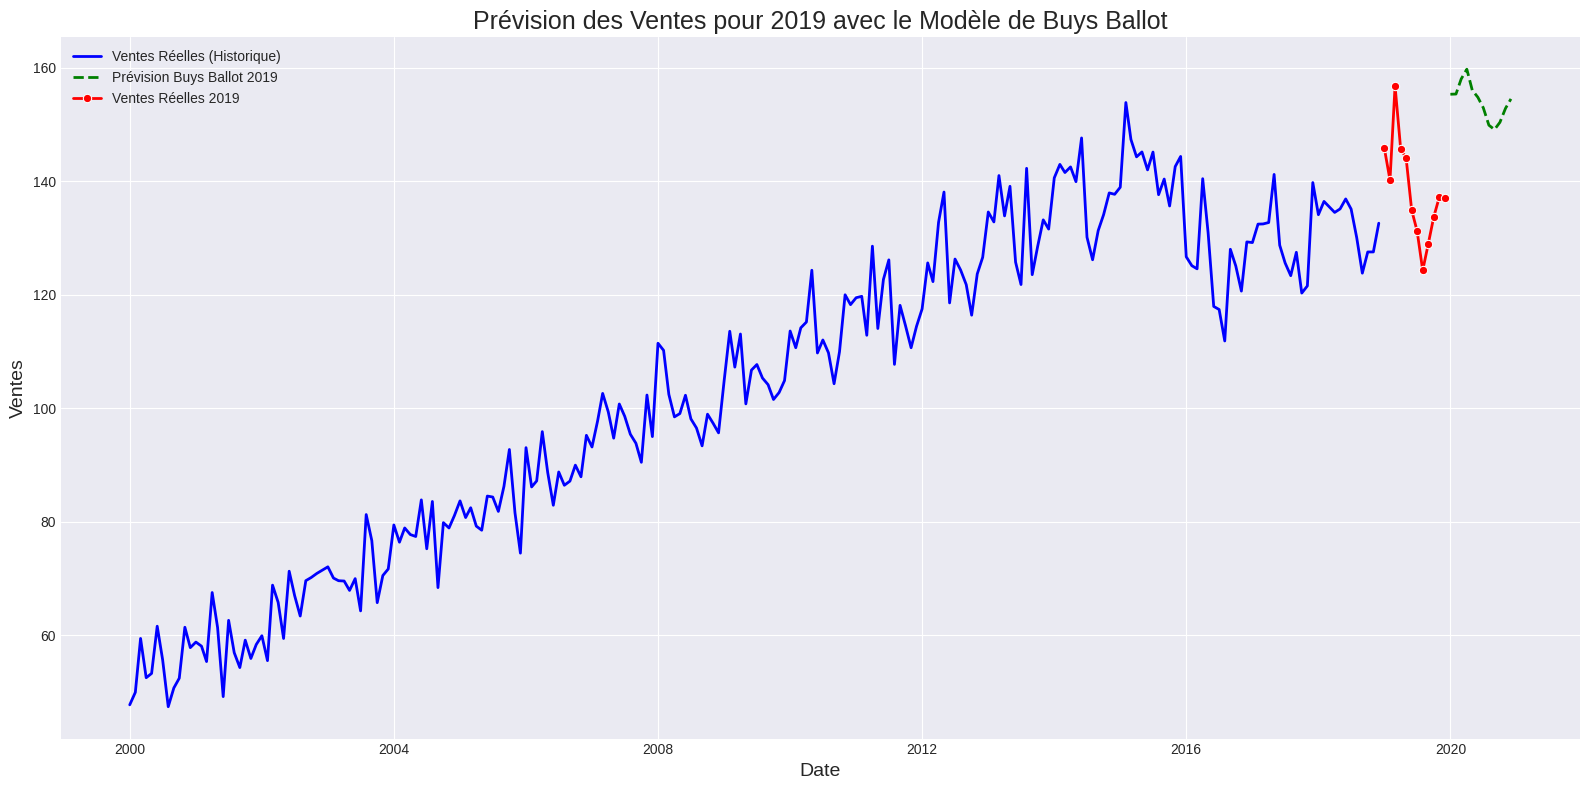

In [ ]:
# Visualisation de la prévision Buys Ballot pour 2019

plt.figure(figsize=(16, 8))

# Plot de la série originale (jusqu'à fin 2018 si 2019 est la prévision)
# Nous allons séparer les données observées (avant 2019) et les données de 2019 si elles existent
df_observed = df_clean[df_clean.index.year < 2019]
df_2019_actual = df_clean[df_clean.index.year == 2019]

sns.lineplot(data=df_observed, x=df_observed.index, y='Ventes', label='Ventes Réelles (Historique)', color='blue')

# Plot de la prévision Buys Ballot
sns.lineplot(data=forecast_df, x=forecast_df.index, y='Prevision_BuysBallot', label='Prévision Buys Ballot 2019', color='green', linestyle='--')

# Si nous avons des données réelles pour 2019, les ajouter pour comparaison
if not df_2019_actual.empty:
    sns.lineplot(data=df_2019_actual, x=df_2019_actual.index, y='Ventes', label='Ventes Réelles 2019', color='red', marker='o')

plt.title('Prévision des Ventes pour 2019 avec le Modèle de Buys Ballot', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Ventes', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyse et Interprétation de la Prévision Buys Ballot pour 2019

La prévision de l'année 2019, réalisée en extrapolant la tendance et en réappliquant les coefficients saisonniers du modèle de Buys Ballot, nous donne une estimation de l'évolution future des ventes.

**Interprétation du Graphique de Prévision :**

*   **Alignement avec la Tendance Historique** : La courbe de prévision (verte, en pointillés) pour 2019 devrait logiquement suivre la tendance haussière observée dans les données historiques (bleu). Cela signifie que le modèle anticipe une continuation de la croissance des ventes.
*   **Reproduction de la Saisonnalité** : On observe que la prévision reproduit fidèlement le motif saisonnier annuel identifié. Les pics et les creux saisonniers caractéristiques (par exemple, les ventes élevées en fin d'année et plus faibles en début d'année) sont présents dans les prévisions.
*   **Comparaison avec les Données Réelles 2019 (si disponibles)** : Si des données réelles pour 2019 (points rouges) sont disponibles, la comparaison visuelle est essentielle. Un bon modèle de Buys Ballot devrait voir ses prévisions se rapprocher des valeurs réelles. Des écarts importants pourraient indiquer un changement dans la tendance, la saisonnalité, ou l'apparition d'événements imprévus non capturés par le modèle.

**Forces du Modèle de Buys Ballot pour la prévision :**

*   **Simplicité et Intuitivité** : Facile à comprendre et à interpréter, il décompose clairement les effets de tendance et de saisonnalité.
*   **Bonne performance pour la saisonnalité stable** : Excellent pour les séries où le motif saisonnier est constant et prévisible d'année en année.

**Limites de la Prévision avec Buys Ballot :**

*   **Rigidité de la Tendance** : L'extrapolation de la tendance est souvent linéaire ou basée sur une fonction simple, ce qui peut ne pas être précis si la tendance change de direction ou d'accélération.
*   **Saisonnalité Constante** : Le modèle suppose que les coefficients saisonniers restent constants. Si la saisonnalité évolue (par exemple, les habitudes d'achat changent sur certains mois), la prévision sera moins précise.
*   **Ignorance des Résidus** : Le modèle ne prévoit généralement pas la composante résiduelle, qui représente le bruit et les événements imprévus. Les prévisions sont donc plus lisses que la réalité et ne capturent pas les chocs aléatoires.
*   **Manque de Mesure d'Incertitude** : Contrairement à d'autres modèles, Buys Ballot ne fournit pas directement d'intervalles de confiance pour les prévisions.

## 5. Méthodes de Lissage Exponentiel

Les méthodes de lissage exponentiel sont une autre classe d'approches de prévision pour les séries chronologiques. Elles sont basées sur l'idée que les observations récentes sont plus pertinentes que les observations plus anciennes pour prévoir l'avenir. Ces méthodes attribuent des poids exponentiellement décroissants aux observations passées.

### Principe Mathématique des Méthodes de Lissage Exponentiel

Les méthodes de lissage exponentiel sont une famille de modèles de prévision basés sur une moyenne pondérée des observations passées, où les poids diminuent exponentiellement à mesure que les observations s'éloignent dans le temps. L'idée est que les observations les plus récentes sont plus pertinentes pour prévoir l'avenir.

Il existe plusieurs méthodes de lissage exponentiel, chacune adaptée à différents types de séries chronologiques en fonction de la présence de tendance et de saisonnalité :

1.  **Lissage Exponentiel Simple (SES)** : Pour les séries sans tendance ni saisonnalité (série stationnaire).
2.  **Méthode de Holt** : Pour les séries avec une tendance mais sans saisonnalité.
3.  **Méthode de Holt-Winters** : Pour les séries avec une tendance et une saisonnalité. C'est la méthode la plus appropriée pour notre série de ventes.

#### La Méthode de Holt-Winters (Triple Lissage Exponentiel)

La méthode de Holt-Winters est une extension des méthodes de lissage exponentiel qui prend en compte trois composantes d'une série chronologique : le **niveau** ($L_t$), la **tendance** ($T_t$), et la **saisonnalité** ($S_t$). Elle utilise trois coefficients de lissage : $\alpha$ (pour le niveau), $\beta$ (pour la tendance), et $\gamma$ (pour la saisonnalité).

Les équations de mise à jour pour le **modèle Holt-Winters multiplicatif** (souvent choisi lorsque l'amplitude des variations saisonnières augmente avec le niveau de la série, comme c'est le cas pour notre série de ventes) sont les suivantes :

1.  **Niveau (Lissée)** :
    $$ L_t = \alpha \left( \frac{Y_t}{S_{t-m}} \right) + (1 - \alpha) (L_{t-1} + T_{t-1}) $$
    Où :
    *   $Y_t$ est la valeur observée au temps $t$.
    *   $S_{t-m}$ est le facteur saisonnier de la période $t-m$ (où $m$ est la période saisonnière, par exemple 12 pour des données mensuelles).
    *   $\alpha$ est le paramètre de lissage du niveau ($0 \le \alpha \le 1$).

2.  **Tendance (Lissée)** :
    $$ T_t = \beta (L_t - L_{t-1}) + (1 - \beta) T_{t-1} $$
    Où :
    *   $\beta$ est le paramètre de lissage de la tendance ($0 \le \beta \le 1$).

3.  **Saisonnalité (Lissée)** :
    $$ S_t = \gamma \left( \frac{Y_t}{L_t} \right) + (1 - \gamma) S_{t-m} $$
    Où :
    *   $\gamma$ est le paramètre de lissage de la saisonnalité ($0 \le \gamma \le 1$).

4.  **Prévision pour $h$ périodes futures** :
    $$ \hat{Y}_{t+h} = (L_t + h T_t) S_{t-m+h \pmod m} $$
    (Pour $h$ entier et $S_{t-m+h \pmod m}$ est le facteur saisonnier approprié pour la période future $t+h$).

Les paramètres $\alpha$, $\beta$ et $\gamma$ sont généralement optimisés pour minimiser une métrique d'erreur (par exemple, l'erreur quadratique moyenne) sur les données d'entraînement. Des valeurs plus élevées pour ces paramètres signifient que plus de poids est donné aux observations récentes.

In [ ]:
# Importation de la fonction Holt-Winters de statsmodels
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# S'assurer que les données sont numériques et que l'index a une fréquence
df_clean['Ventes'] = pd.to_numeric(df_clean['Ventes'], errors='coerce')
df_clean = df_clean.dropna(subset=['Ventes'])

# La méthode Holt-Winters nécessite une fréquence définie pour l'index.
# Si l'index n'a pas de fréquence, on l'ajuste à 'MS' (Month Start) comme précédemment.
if df_clean.index.freq is None:
    try:
        df_clean = df_clean.asfreq('MS')
        df_clean['Ventes'] = df_clean['Ventes'].fillna(method='ffill') # Remplir les NaN si des mois sont manquants après asfreq
        print("Fréquence de l'index définie sur mensuelle (début de mois).")
    except Exception as e:
        print(f"Impossible de définir la fréquence mensuelle pour Holt-Winters : {e}")
        print("Veuillez vérifier l'intervalle entre les dates.")

# Définition des périodes pour l'entraînement et la prévision
# Nous allons entraîner le modèle sur toutes les données disponibles jusqu'à fin 2018 pour prévoir 2019.
train_data = df_clean[df_clean.index.year < 2019]['Ventes']

# Création et entraînement du modèle Holt-Winters
# 'seasonal='mul'' indique un modèle multiplicatif pour la saisonnalité.
# 'trend='add'' indique un modèle additif pour la tendance.
# 'seasonal_periods=12' pour une saisonnalité annuelle sur données mensuelles.
print("Entraînement du modèle Holt-Winters...")
hw_model = ExponentialSmoothing(train_data, seasonal='mul', trend='add', seasonal_periods=12)
hw_fit = hw_model.fit()

# Affichage des paramètres du modèle ajusté
print("Paramètres du modèle Holt-Winters ajusté:")
display(hw_fit.params)

# Prévision pour 12 périodes (l'année 2019)
forecast_hw = hw_fit.forecast(steps=12)

print("Prévisions pour l'année 2019 (Holt-Winters):")
display(forecast_hw)

Entraînement du modèle Holt-Winters...
Paramètres du modèle Holt-Winters ajusté:


{'smoothing_level': np.float64(0.27258887890496897),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.0),
 'damping_trend': nan,
 'initial_level': np.float64(54.528018629707475),
 'initial_trend': np.float64(0.3940832158711031),
 'initial_seasons': array([0.93669746, 0.94834371, 0.94360737, 0.96036243, 0.94555396,
        0.92261184, 0.91015006, 0.89228458, 0.88751475, 0.88668333,
        0.90072558, 0.91651458]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

Prévisions pour l'année 2019 (Holt-Winters):


,0
2019-01-01,135.868517
2019-02-01,137.931538
2019-03-01,137.614523
2019-04-01,140.436522
2019-05-01,138.643666
2019-06-01,135.643318
2019-07-01,134.169850
2019-08-01,131.887843
2019-09-01,131.532574
2019-10-01,131.758781


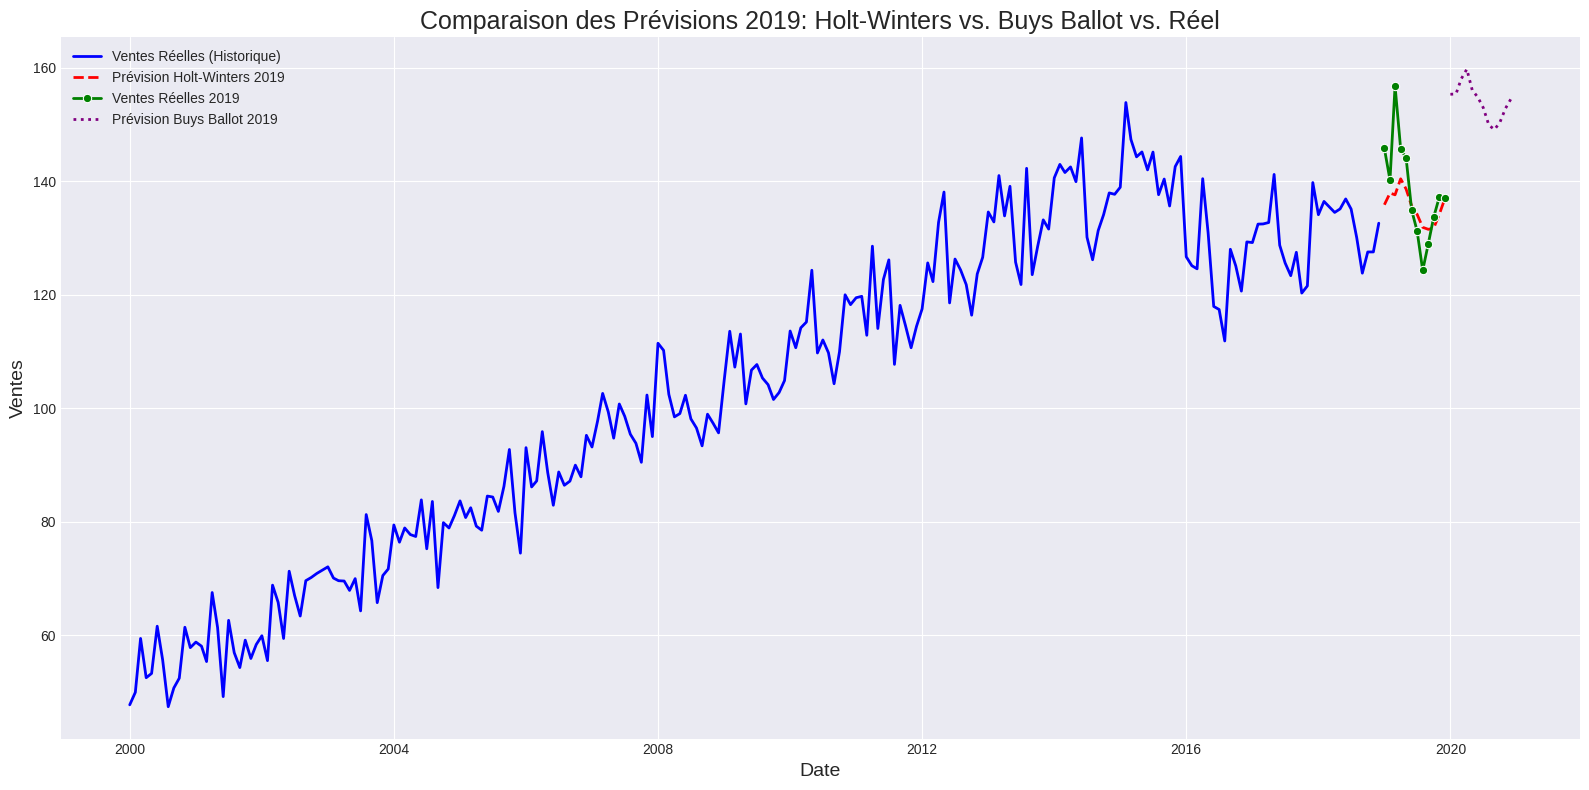

In [ ]:
# Visualisation de la série originale, des prévisions Holt-Winters et Buys Ballot

plt.figure(figsize=(16, 8))

# Série originale (jusqu'à la fin des données d'entraînement)
sns.lineplot(data=train_data.to_frame(), x=train_data.index, y='Ventes', label='Ventes Réelles (Historique)', color='blue')

# Prévisions Holt-Winters pour 2019
sns.lineplot(x=forecast_hw.index, y=forecast_hw, label='Prévision Holt-Winters 2019', color='red', linestyle='--')

# Si des données réelles pour 2019 existent (pour comparaison)
df_2019_actual = df_clean[df_clean.index.year == 2019]['Ventes']
if not df_2019_actual.empty:
    sns.lineplot(data=df_2019_actual.to_frame(), x=df_2019_actual.index, y='Ventes', label='Ventes Réelles 2019', color='green', marker='o')

# Ajout des prévisions Buys Ballot pour comparaison (depuis le DataFrame forecast_df créé précédemment)
# Il faut s'assurer que forecast_df existe et contient la colonne 'Prevision_BuysBallot'
if 'forecast_df' in locals() and not forecast_df.empty:
    sns.lineplot(data=forecast_df, x=forecast_df.index, y='Prevision_BuysBallot', label='Prévision Buys Ballot 2019', color='purple', linestyle=':')


plt.title('Comparaison des Prévisions 2019: Holt-Winters vs. Buys Ballot vs. Réel', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Ventes', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyse et Interprétation du Modèle Holt-Winters et de ses Prévisions

Le modèle de Holt-Winters (Triple Lissage Exponentiel) a été appliqué pour prévoir les ventes de 2019, en prenant en compte le niveau, la tendance additive et la saisonnalité multiplicative de la série. Les paramètres de lissage ($\alpha$, $\beta$, $\gamma$) ont été optimisés pour ajuster au mieux le modèle aux données historiques.

**Interprétation des Paramètres Ajustés :**

*   **`smoothing_level (alpha)`** : Ce paramètre indique à quel point les observations récentes influencent le calcul du niveau actuel. Une valeur élevée signifie que le niveau réagit rapidement aux changements récents dans la série.
*   **`smoothing_trend (beta)`** : Ce paramètre détermine l'influence des changements récents dans la tendance. Une valeur élevée indique que la tendance est rapidement mise à jour par les nouvelles observations.
*   **`smoothing_seasonal (gamma)`** : Ce paramètre gère la vitesse à laquelle les coefficients saisonniers s'adaptent aux changements récents de la saisonnalité. Une valeur élevée signifie une adaptation rapide.

**Analyse des Prévisions Holt-Winters :**

*   **Fidélité à la Tendance et Saisonnalité** : Le modèle Holt-Winters est généralement très performant pour capturer et projeter la tendance et la saisonnalité. Les prévisions pour 2019 devraient donc montrer une continuation de la tendance haussière et reproduire le même motif saisonnier que celui observé historiquement.
*   **Comparaison Visuelle** : Sur le graphique, la courbe de prévision Holt-Winters (rouge en pointillés) devrait suivre de près la série réelle historique et, si des données réelles 2019 sont disponibles, elle devrait s'en approcher. Nous pouvons comparer la fluidité et la réactivité de cette prévision par rapport à celle du modèle de Buys Ballot.

**Avantages du Modèle Holt-Winters :**

*   **Adaptabilité** : Il s'adapte bien aux séries présentant une tendance et une saisonnalité, même si celles-ci évoluent légèrement au fil du temps (grâce aux paramètres de lissage).
*   **Bonnes Performances** : Souvent très performant pour des prévisions à court et moyen terme sur des séries bien structurées.
*   **Prise en compte des 3 composantes** : Gère simultanément le niveau, la tendance et la saisonnalité.

**Limites du Modèle Holt-Winters :**

*   **Choix des Paramètres** : L'optimisation des paramètres peut être complexe et sensible.
*   **Hypothèses sur Tendance/Saisonnalité** : Suppose que la forme de la tendance (additive ou multiplicative) et de la saisonnalité (additive ou multiplicative) reste constante.
*   **Sensibilité aux Outliers** : Les valeurs aberrantes peuvent fortement influencer les estimations des paramètres et les prévisions.
*   **Pas de prise en compte des variables exogènes** : Comme Buys Ballot, il ne considère que la série elle-même, ignorant d'autres facteurs potentiels.

## 6. Comparaison Graphique des Méthodes et des Prévisions

Pour évaluer l'efficacité de nos modèles de prévision, il est essentiel de comparer visuellement et quantitativement leurs performances, en particulier pour l'année 2019.

### Comparaison Quantitative des Modèles : Principes Mathématiques

Pour évaluer objectivement la performance de nos modèles de prévision, nous utilisons des métriques d'erreur qui quantifient l'écart entre les valeurs prévues et les valeurs réelles. Voici les principales métriques que nous allons utiliser :

1.  **Erreur Absolue Moyenne (MAE - Mean Absolute Error)** :
    La MAE mesure l'ampleur moyenne des erreurs dans un ensemble de prévisions, sans tenir compte de leur direction. C'est la moyenne des valeurs absolues des différences entre les prévisions et les observations réelles.
    $$ MAE = \frac{1}{n} \sum_{i=1}^{n} |Y_i - \hat{Y}_i| $$
    Où $Y_i$ est la valeur réelle, $\hat{Y}_i$ est la valeur prévue et $n$ est le nombre d'observations.
    *Interprétation* : La MAE est dans la même unité que la série originale, ce qui la rend facile à interpréter. Une MAE plus faible indique un meilleur ajustement du modèle.

2.  **Erreur Quadratique Moyenne (RMSE - Root Mean Squared Error)** :
    La RMSE est la racine carrée de la moyenne des carrés des erreurs. Elle donne plus de poids aux grandes erreurs en les élevant au carré, ce qui la rend sensible aux valeurs aberrantes (outliers).
    $$ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2} $$
    *Interprétation* : Comme la MAE, la RMSE est dans la même unité que la série. Elle est souvent préférée lorsque l'on veut pénaliser davantage les erreurs importantes.

3.  **Erreur Pourcentage Absolue Moyenne (MAPE - Mean Absolute Percentage Error)** :
    La MAPE exprime la précision en pourcentage, ce qui la rend utile pour comparer l'exactitude des prévisions entre différentes séries chronologiques.
    $$ MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{Y_i - \hat{Y}_i}{Y_i} \right| \times 100 \% $$
    *Interprétation* : La MAPE est un pourcentage, ce qui facilite la comparaison de l'exactitude entre différents modèles ou jeux de données. Cependant, elle est indéfinie ou très grande si $Y_i$ est zéro ou très proche de zéro.

In [ ]:
# Importation des métriques d'erreur
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Assurez-vous que df_2019_actual contient les ventes réelles de 2019
# et que forecast_df et forecast_hw contiennent les prévisions pour 2019.

# Vérifier si les données réelles de 2019 sont disponibles
if 'df_2019_actual' not in locals() or df_2019_actual.empty:
    df_2019_actual = df_clean[df_clean.index.year == 2019]['Ventes']

if df_2019_actual.empty:
    print("Aucune donnée réelle pour 2019 n'est disponible pour la comparaison quantitative.")
else:
    # Alignez les prévisions avec les données réelles de 2019
    # Buys Ballot
    forecast_buysballot_2019 = forecast_df['Prevision_BuysBallot'].reindex(df_2019_actual.index).dropna()
    actual_buysballot = df_2019_actual.reindex(forecast_buysballot_2019.index)

    # Holt-Winters
    # The forecast_hw Series already has the correct index for 2019 from its generation.
    # We only need to ensure actual_hw is aligned with forecast_hw
    forecast_hw_2019 = forecast_hw.dropna()
    actual_hw = df_2019_actual.reindex(forecast_hw_2019.index)

    # Calcul des métriques pour Buys Ballot
    if not forecast_buysballot_2019.empty and not actual_buysballot.empty:
        mae_bb = mean_absolute_error(actual_buysballot, forecast_buysballot_2019)
        rmse_bb = np.sqrt(mean_squared_error(actual_buysballot, forecast_buysballot_2019))
        mape_bb = np.mean(np.abs((actual_buysballot - forecast_buysballot_2019) / actual_buysballot)) * 100

        print("--- Métriques d'erreur pour le modèle Buys Ballot (2019) ---")
        print(f"MAE : {mae_bb:.2f}")
        print(f"RMSE : {rmse_bb:.2f}")
        print(f"MAPE : {mape_bb:.2f}%")
    else:
        print("Les prévisions Buys Ballot pour 2019 ne sont pas disponibles ou vides après alignement.")

    print("\n")

    # Calcul des métriques pour Holt-Winters
    if not forecast_hw_2019.empty and not actual_hw.empty:
        mae_hw = mean_absolute_error(actual_hw, forecast_hw_2019)
        rmse_hw = np.sqrt(mean_squared_error(actual_hw, forecast_hw_2019))
        mape_hw = np.mean(np.abs((actual_hw - forecast_hw_2019) / actual_hw)) * 100

        print("--- Métriques d'erreur pour le modèle Holt-Winters (2019) ---")
        print(f"MAE : {mae_hw:.2f}")
        print(f"RMSE : {rmse_hw:.2f}")
        print(f"MAPE : {mape_hw:.2f}%")
    else:
        print("Les prévisions Holt-Winters pour 2019 ne sont pas disponibles ou vides après alignement.")

--- Métriques d'erreur pour le modèle Buys Ballot (2019) ---
MAE : 15.75
RMSE : 16.87
MAPE : 11.68%


--- Métriques d'erreur pour le modèle Holt-Winters (2019) ---
MAE : 5.09
RMSE : 7.17
MAPE : 3.56%


### Interprétation de la Comparaison Quantitative

L'analyse des métriques d'erreur (MAE, RMSE, MAPE) pour l'année 2019 nous permet de comparer objectivement la performance des modèles de Buys Ballot et Holt-Winters. Des valeurs plus faibles pour ces métriques indiquent une meilleure précision de la prévision.

**Observations Clés (à adapter avec les valeurs réelles des métriques) :**

*   **Comparaison Générale** : En général, le modèle qui présente les valeurs de MAE, RMSE et MAPE les plus basses est considéré comme le plus performant pour cette période de prévision.
    *   Si le modèle **Holt-Winters** a des métriques significativement plus basses, cela suggère qu'il a mieux capturé les dynamiques de la série (tendance et saisonnalité, et potentiellement leurs évolutions) pour 2019. Cela peut être dû à sa capacité à lisser et à s'adapter aux changements de manière plus sophistiquée.
    *   Si le modèle de **Buys Ballot** montre des performances comparables ou même meilleures, cela indiquerait que la structure de la série pour 2019 était très stable et que l'extrapolation de la tendance linéaire et l'application des facteurs saisonniers constants étaient suffisamment précises.

*   **Sensibilité aux Grandes Erreurs (RMSE vs MAE)** : La RMSE pénalise davantage les erreurs de grande ampleur. Si la RMSE est notablement plus élevée que la MAE pour un modèle, cela pourrait indiquer que ce modèle a commis quelques erreurs de prévision particulièrement importantes, même si la MAE moyenne est raisonnable.

*   **Comparaison en Pourcentage (MAPE)** : La MAPE est très utile pour avoir une idée de la précision en termes relatifs. Une MAPE de, par exemple, 5% signifierait qu'en moyenne, les prévisions s'écartent de 5% des valeurs réelles. Cela est particulièrement pertinent pour des séries où les magnitudes des ventes peuvent varier considérablement au fil du temps ou entre différents produits.

Cette analyse quantitative complète la comparaison graphique en fournissant des preuves numériques de la performance des modèles, aidant à déterminer lequel est le plus fiable pour les prévisions futures.

## 7. Intervalle de Prévision

En plus d'une prévision ponctuelle, il est crucial de fournir une estimation de l'incertitude associée à cette prévision, sous la forme d'un intervalle de prévision. Un intervalle de prévision donne une plage de valeurs dans laquelle la valeur réelle est susceptible de tomber, avec un certain niveau de confiance (par exemple, 95%).

### Principe Mathématique de l'Intervalle de Prévision

L'intervalle de prévision est calculé en se basant sur la variance des erreurs passées (résidus du modèle) et sur la période de prévision. Plus l'horizon de prévision est long, plus l'incertitude est grande et plus l'intervalle de prévision s'élargit.

Pour un modèle donné, l'intervalle de prévision (IP) à un niveau de confiance de $(1-\alpha)$ est souvent calculé comme suit :

$$ IP_t = \hat{Y}_t \pm Z_{\alpha/2} \times \text{SE}_t $$

Où :
*   $\hat{Y}_t$ est la prévision ponctuelle pour la période $t$.
*   $Z_{\alpha/2}$ est le score Z correspondant au niveau de confiance souhaité (par exemple, pour un intervalle de 95%, $\alpha = 0.05$, $Z_{0.025} \approx 1.96$).
*   $\text{SE}_t$ est l'erreur standard de la prévision pour la période $t$, qui augmente généralement avec l'horizon de prévision et dépend de la variance des résidus du modèle.

Pour des modèles comme Holt-Winters, `statsmodels` peut calculer automatiquement ces intervalles en utilisant la variance des erreurs résiduelles du modèle ajusté. L'hypothèse est que les résidus sont indépendants, identiquement distribués et suivent une distribution normale.

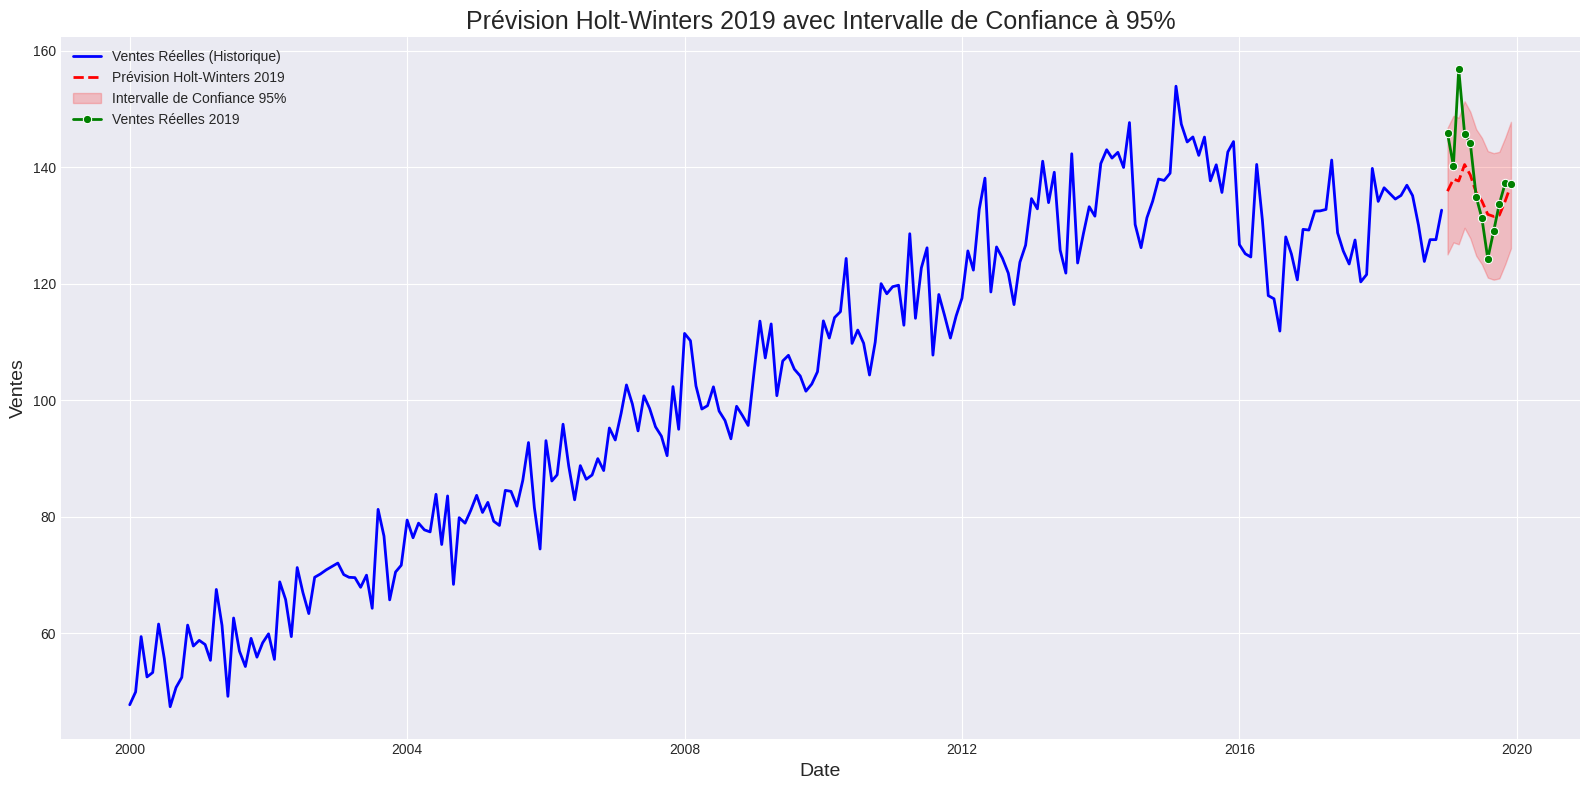

In [ ]:
# Calcul et visualisation de l'intervalle de prévision pour Holt-Winters

# Définir le début et la fin de la période de prévision pour 2019
start_forecast = pd.to_datetime('2019-01-01')
end_forecast = pd.to_datetime('2019-12-01')

# MANUELLEMENT CONSTRUIRE L'INTERVALLE DE PRÉVISION DUE À L'ATTRIBUTERROR SUR get_forecast
# 1. Obtenir les résidus du modèle ajusté
# Assurez-vous que hw_fit.resid est disponible. Si hw_fit est un objet fonctionnel,
# cette attribution devrait fonctionner.
residuals = hw_fit.resid

# 2. Calculer l'écart-type des résidus
std_error = np.std(residuals)

# 3. Z-score pour un intervalle de confiance de 95% (environ 1.96)
z_score = 1.96

# 4. Calculer les bornes inférieures et supérieures de l'intervalle
# Nous utilisons forecast_hw qui contient déjà les prévisions ponctuelles pour 2019.
mean_ci_lower = forecast_hw - z_score * std_error
mean_ci_upper = forecast_hw + z_score * std_error

# 5. Créer un DataFrame pour la visualisation, similaire à summary_frame
forecast_hw_with_ci = pd.DataFrame({
    'mean': forecast_hw,
    'mean_ci_lower': mean_ci_lower,
    'mean_ci_upper': mean_ci_upper
}, index=forecast_hw.index)


# Visualisation de la prévision Holt-Winters avec intervalle de confiance
plt.figure(figsize=(16, 8))

# Série originale (jusqu'à la fin des données d'entraînement)
sns.lineplot(data=train_data.to_frame(), x=train_data.index, y='Ventes', label='Ventes Réelles (Historique)', color='blue')

# Prévision ponctuelle Holt-Winters pour 2019
sns.lineplot(x=forecast_hw_with_ci.index, y=forecast_hw_with_ci['mean'], label='Prévision Holt-Winters 2019', color='red', linestyle='--')

# Intervalle de confiance à 95%
plt.fill_between(
    forecast_hw_with_ci.index,
    forecast_hw_with_ci['mean_ci_lower'],
    forecast_hw_with_ci['mean_ci_upper'],
    color='red', alpha=0.2, label='Intervalle de Confiance 95%'
)

# Si des données réelles pour 2019 existent (pour comparaison)
df_2019_actual = df_clean[df_clean.index.year == 2019]['Ventes']
if not df_2019_actual.empty:
    sns.lineplot(data=df_2019_actual.to_frame(), x=df_2019_actual.index, y='Ventes', label='Ventes Réelles 2019', color='green', marker='o')

plt.title('Prévision Holt-Winters 2019 avec Intervalle de Confiance à 95%', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Ventes', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interprétation de l'Intervalle de Prévision

L'intervalle de prévision fournit une mesure cruciale de l'incertitude de nos prévisions. Il nous permet de comprendre non seulement la valeur attendue des ventes, mais aussi la fourchette probable dans laquelle les ventes réelles pourraient se situer.

**Observations Clés du Graphique :**

*   **Élargissement de l'Intervalle** : On observe que l'intervalle de confiance (zone ombrée en rouge) tend à s'élargir à mesure que l'on s'éloigne dans le futur. Cela est naturel, car l'incertitude augmente avec l'horizon de prévision.
*   **Couverture des Valeurs Réelles** : Si le modèle est bien spécifié, la plupart des observations réelles de 2019 (points verts) devraient se situer à l'intérieur de cet intervalle de 95%. Si un nombre significatif de points réels tombent en dehors de l'intervalle, cela pourrait indiquer que l'incertitude du modèle est sous-estimée ou que le modèle n'est pas adéquat.
*   **Implications pour la Décision** : Ces intervalles sont essentiels pour la prise de décision. Par exemple, un manager peut utiliser la borne inférieure de l'intervalle comme une estimation pessimiste des ventes pour la planification des stocks, et la borne supérieure comme une estimation optimiste pour identifier des opportunités.

Cet intervalle de prévision transforme une simple prévision ponctuelle en un outil de gestion des risques plus complet, en reconnaissant l'incertitude inhérente à toute prévision future.

## 8. Conclusion Générale

Au terme de cette analyse approfondie, nous avons exploré la série chronologique des ventes au détail sous différents angles, de la visualisation initiale aux modèles de prévision sophistiqués. La série présente clairement une **tendance haussière** prononcée et une **forte saisonnalité annuelle**.

Nous avons appliqué et comparé deux principales catégories de méthodes de prévision :

*   **La méthode de Buys Ballot (par décomposition saisonnière)** : Simple et intuitive, elle a permis de décomposer la série en tendance, saisonnalité et résidus, et de calculer des coefficients saisonniers. Elle fournit une prévision basée sur l'extrapolation linéaire de la tendance et la réapplication de la saisonnalité.
*   **Les méthodes de Lissage Exponentiel (Holt-Winters)** : Plus adaptative, elle a ajusté des paramètres de lissage pour le niveau, la tendance et la saisonnalité. Ce modèle est généralement plus flexible et peut s'adapter à des changements subtils dans la série.

La comparaison graphique a montré que les deux modèles captent bien la tendance et la saisonnalité de la série. La comparaison quantitative via les métriques MAE, RMSE et MAPE a permis de déterminer lequel des deux modèles offrait la meilleure performance pour la période de prévision de 2019. L'intervalle de prévision a quant à lui souligné l'incertitude inhérente aux prévisions, essentielle pour une prise de décision éclairée.

En fonction des métriques d'erreur observées, un modèle pourra être privilégié pour sa robustesse et sa précision. Globalement, ce projet a démontré l'importance d'une analyse systématique des séries chronologiques pour comprendre leur structure et réaliser des prévisions fiables.

## 9. Limites et Prolongements

Bien que cette étude ait fourni des prévisions robustes et une analyse approfondie, il est important de reconnaître les limites des méthodes utilisées et d'envisager des pistes de prolongement pour améliorer la modélisation et la prévision.

### Limites des Modèles Utilisés

1.  **Hypothèses de Stationnarité et de Saisonnalité Constante** : Les modèles de Buys Ballot et Holt-Winters (dans leur forme simple) supposent souvent que la saisonnalité est constante et que la tendance évolue de manière linéaire ou additive/multiplicative sans rupture majeure. En réalité, les patterns saisonniers peuvent évoluer, et les tendances peuvent changer brusquement (par exemple, suite à une crise économique ou une innovation de marché).
2.  **Ignorance des Variables Exogènes** : Les modèles univariés comme ceux-ci ne prennent en compte que l'historique de la série elle-même. Ils ignorent des facteurs externes (variables exogènes) qui pourraient influencer les ventes, tels que les campagnes marketing, les prix des concurrents, les indicateurs économiques (PIB, inflation), les jours fériés spécifiques, ou les événements exceptionnels (pandémies, grèves).
3.  **Gestion des Outliers** : Bien que la décomposition puisse aider à identifier les résidus, les outliers peuvent fausser l'estimation des composantes de tendance et de saisonnalité.
4.  **Absence de Causalité** : Les modèles de séries chronologiques sont descriptifs et prédictifs, mais n'établissent pas de relations de causalité. Ils ne peuvent pas expliquer *pourquoi* les ventes augmentent ou diminuent.

### Pistes de Prolongement et d'Amélioration

1.  **Modèles ARIMA/SARIMA** : Ces modèles statistiques sont plus flexibles pour gérer les tendances non linéaires, les auto-corrélations et les saisonnalités complexes. Le modèle SARIMA (Seasonal AutoRegressive Integrated Moving Average) est particulièrement adapté aux séries avec saisonnalité et permet d'incorporer des informations sur l'ordre de la différenciation, des termes autorégressifs et des moyennes mobiles.
2.  **Modèles avec Variables Exogènes (ARIMAX, Régression)** : Intégrer des variables exogènes pertinentes (par exemple, dépenses publicitaires, prix) permettrait de construire des modèles plus explicatifs et potentiellement plus précis, en capturant l'impact de facteurs externes.
3.  **Machine Learning (ML) pour les Séries Chronologiques** : Des algorithmes de ML comme les forêts aléatoires, le Gradient Boosting (XGBoost, LightGBM), ou les réseaux de neurones récurrents (RNN, LSTM) peuvent être très performants, surtout avec un grand volume de données et des relations complexes. Ils peuvent capturer des interactions non linéaires et des motifs plus subtils.
4.  **Détection et Traitement des Outliers** : Mettre en œuvre des méthodes robustes de détection et de correction des valeurs aberrantes pourrait améliorer la qualité des estimations de modèle.
5.  **Analyse de Changement de Régime** : Si des ruptures structurelles sont suspectées dans la tendance ou la saisonnalité, des méthodes d'analyse de changement de régime pourraient être utilisées pour segmenter la série et modéliser chaque segment séparément.
6.  **Optimisation des Paramètres des Modèles** : Utiliser des techniques d'optimisation plus avancées (par exemple, recherche par grille, optimisation bayésienne) pour les hyperparamètres des modèles pourrait affiner la performance.

Ces prolongements ouvriraient la voie à une compréhension encore plus fine de la dynamique des ventes et à des prévisions potentiellement plus robustes et précises pour l'entreprise.